# 12. GPT — Causal Language Model

**Цель:** Реализовать GPT-подобную модель (Decoder-only), различные стратегии сэмплирования (greedy, top-k, top-p, temperature) и генерацию текста.

---

In [1]:
# Импорты: стандартные библиотеки и PyTorch
import sys, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Автовыбор устройства: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


2026-06-05 23:13:11,762 [INFO] gpt: Using device: cuda


## 12.1 GPT-архитектура (Decoder-only)

**Отличие от полного трансформера:**
- Только декодерные блоки (без cross-attention)
- Каузальный self-attention (нельзя заглядывать в будущее)
- Авторегрессивная генерация: каждый новый токен зависит от предыдущих

In [2]:
# Специальные токены: BOS — начало, EOS — конец, PAD — заполнитель
BOS, EOS, PAD = 0, 1, 2


class MultiHeadAttention(nn.Module):
    """Многоголовое внимание с поддержкой каузальной маски."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model должно делиться на n_heads"
        self.d_k = d_model // n_heads  # размерность одной головы
        self.W_Q = nn.Linear(d_model, d_model, bias=False)  # проекция Query
        self.W_K = nn.Linear(d_model, d_model, bias=False)  # проекция Key
        self.W_V = nn.Linear(d_model, d_model, bias=False)  # проекция Value
        self.W_O = nn.Linear(d_model, d_model, bias=False)  # выходная проекция
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, causal=True, pad_mask=None):
        batch = Q.size(0)
        n_heads = self.W_O.out_features // self.d_k
        # Преобразуем: (batch, seq, d_model) -> (batch, n_heads, seq, d_k)
        Q = self.W_Q(Q).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch, -1, n_heads, self.d_k).transpose(1, 2)
        # Скалярное произведение с масштабированием
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if causal:
            # Каузальная маска: запрещаем заглядывать в будущее
            seq_len = Q.size(-2)
            causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=Q.device), diagonal=1).bool()
            scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        if pad_mask is not None:
            # Маска по padding-токенам
            scores = scores.masked_fill(pad_mask.unsqueeze(1).unsqueeze(2) == 0, float('-inf'))

        attn = self.dropout(F.softmax(scores, dim=-1))
        output = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.W_O.out_features)
        return self.W_O(output)


class FeedForward(nn.Module):
    """Двухслойная полносвязная сеть с GeLU."""
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 4 * d_model)      # расширение
        self.fc2 = nn.Linear(4 * d_model, d_model)       # сжатие обратно
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


class DecoderBlock(nn.Module):
    """Один декодерный блок GPT: Self-Attention -> FFN с Skip-Connections."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, dropout)
        self.norm1 = nn.LayerNorm(d_model)   # Pre-Norm перед Attention
        self.norm2 = nn.LayerNorm(d_model)   # Pre-Norm перед FFN
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        # Pre-Norm residual: norm -> attention -> dropout -> + (skip)
        x = x + self.dropout1(self.attention(self.norm1(x), self.norm1(x), self.norm1(x), causal=True, pad_mask=pad_mask))
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x


class GPT(nn.Module):
    """Decoder-only трансформер (GPT-подобная модель)."""
    def __init__(self, vocab_size, d_model=64, n_heads=4, num_layers=6, max_len=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)  # векторные представления токенов

        # Синусоидальные позиционные кодирования (без обучения)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.dropout_pe = nn.Dropout(dropout)

        # Стопка декодерных блоков
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, n_heads, dropout) for _ in range(num_layers)
        ])

        self.output_proj = nn.Linear(d_model, vocab_size)  # проекция на словарь

        # Инициализация Xavier для всех весов
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

        print(f"GPT: vocab={vocab_size}, d_model={d_model}, n_heads={n_heads}, layers={num_layers}, params={sum(p.numel() for p in self.parameters())}")

    def forward(self, x, pad_mask=None):
        # Сумма эмбеддингов + позиционных кодирований
        x = self.dropout_pe(self.embedding(x) * math.sqrt(self.d_model) + self.pe[:, :x.size(1), :])
        for layer in self.layers:
            x = layer(x, pad_mask)
        return self.output_proj(x)  # логиты над словарём

2026-06-05 23:13:14,079 [DEBUG] gpt: Implementing GPT model


## 12.2 Стратегии сэмплирования

| Метод | Описание |
|-------|----------|
| Greedy | argmax — всегда самый вероятный токен |
| Top-k | Выбор из k наиболее вероятных токенов |
| Top-p (nucleus) | Выбор из токенов с кумулятивной вероятностью p |
| Temperature | Масштабирование logits перед softmax |

In [3]:
# Жадный поиск: выбираем токен с максимальной вероятностью
@torch.no_grad()
def generate_greedy(model, input_ids, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :]          # логиты последнего токена
        next_token = logits.argmax(-1, keepdim=True) # argmax = самый вероятный
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids

# Top-k сэмплирование: выбираем из k наиболее вероятных токенов
@torch.no_grad()
def generate_top_k(model, input_ids, k=10, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :]
        values, indices = torch.topk(logits, k, dim=-1)  # берём k лучших
        probs = F.softmax(values, dim=-1)                 # softmax только по ним
        next_token = indices.gather(-1, torch.multinomial(probs, 1))
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids

# Top-p (nucleus) сэмплирование: динамический набор токенов
@torch.no_grad()
def generate_top_p(model, input_ids, p=0.9, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :]
        probs = F.softmax(logits, dim=-1)

        # Сортируем вероятности по убыванию
        sorted_probs, sorted_indices = probs.sort(descending=True, dim=-1)
        cumsum = sorted_probs.cumsum(dim=-1)

        # Отбрасываем токены, у которых кумулятивная вероятность > p
        mask = cumsum - sorted_probs > p
        sorted_probs[mask] = 0
        sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)

        next_token = sorted_indices.gather(-1, torch.multinomial(sorted_probs, 1))
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids

# Temperature-сэмплирование: контролируем «креативность»
@torch.no_grad()
def generate_with_temp(model, input_ids, temperature=1.0, max_new_tokens=20):
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(input_ids)[:, -1, :] / temperature  # масштабируем логиты
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)           # сэмплируем
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        if (next_token == EOS).all():
            break
    return input_ids



2026-06-05 23:13:20,031 [DEBUG] gpt: Implementing sampling strategies
2026-06-05 23:13:20,031 [DEBUG] gpt: All sampling strategies defined


## 12.3 Демонстрация: сравнение стратегий

Обучим маленький GPT на синтетических данных и сравним все 4 подхода.

2026-06-05 23:13:26,243 [INFO] gpt: Preparing data and training GPT
2026-06-05 23:13:26,264 [INFO] gpt: GPT: vocab=20, d_model=32, n_heads=4, layers=4, params=51604
2026-06-05 23:13:27,492 [INFO] gpt: Epoch 0: loss=3.8751
2026-06-05 23:13:30,228 [INFO] gpt: Epoch 10: loss=2.7989
2026-06-05 23:13:32,905 [INFO] gpt: Epoch 20: loss=2.7701
2026-06-05 23:13:35,312 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-05 23:13:35,314 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-05 23:13:35,315 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-05 23:13:35,316 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='D:\\OpenCodeNLLM\\OpenCode\\Transformer_Notebooks\\transformer_learning\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-Oblique.ttf', nam

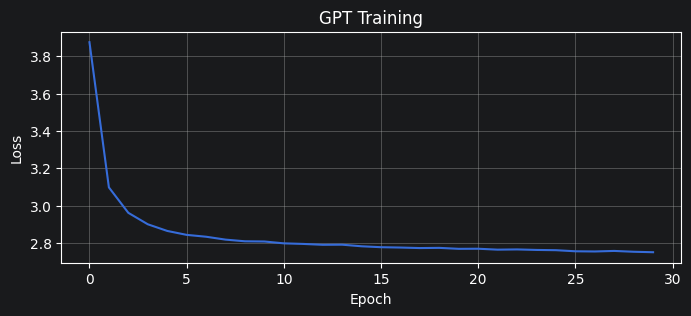

2026-06-05 23:13:35,639 [INFO] gpt: GPT training complete, final loss=2.7514


In [4]:
# Параметры синтетического датасета
vocab_size = 20  # размер словаря (20 уникальных токенов)
max_len = 10      # максимальная длина последовательности


def make_data(num_samples):
    """Генерация синтетических последовательностей с BOS/EOS/PAD."""
    data = []
    for _ in range(num_samples):
        length = np.random.randint(3, max_len - 1)
        seq = [BOS] + np.random.randint(3, vocab_size, size=length).tolist() + [EOS]
        seq = seq + [PAD] * (max_len - len(seq))  # дополняем до max_len
        data.append(seq)
    return torch.tensor(data)


train_data = make_data(2000)  # 2000 обучающих примеров

# Маленький GPT: 4 слоя, 4 головы, размерность 32
gpt = GPT(vocab_size=vocab_size, d_model=32, n_heads=4, num_layers=4, max_len=max_len).to(device)
optimizer = torch.optim.AdamW(gpt.parameters(), lr=0.001)

n_epochs = 30
batch_size = 64
criterion = nn.CrossEntropyLoss(ignore_index=PAD)  # PAD не участвует в loss
losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    perm = torch.randperm(len(train_data))  # перемешиваем данные
    for i in range(0, len(train_data), batch_size):
        idx = perm[i:i+batch_size]
        batch = train_data[idx].to(device)

        # Авторегрессия: input = всё кроме последнего, target = всё кроме первого
        output = gpt(batch[:, :-1])
        loss = criterion(output.reshape(-1, vocab_size), batch[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(train_data) / batch_size)
    losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, loss={avg_loss:.4f}")

# График сходимости
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GPT Training')
plt.grid(True)
plt.show()


In [5]:
# Сравнение всех стратегий сэмплирования на одном промпте
prompt = torch.tensor([[BOS, 5, 12, 8]], device=device)  # промпт из 4 токенов

strategies = {
    'Greedy': lambda: generate_greedy(gpt, prompt.clone(), max_new_tokens=15),
    'Top-k (k=5)': lambda: generate_top_k(gpt, prompt.clone(), k=5, max_new_tokens=15),
    'Top-p (p=0.9)': lambda: generate_top_p(gpt, prompt.clone(), p=0.9, max_new_tokens=15),
    'Temp=0.8': lambda: generate_with_temp(gpt, prompt.clone(), temperature=0.8, max_new_tokens=15),
    'Temp=1.5': lambda: generate_with_temp(gpt, prompt.clone(), temperature=1.5, max_new_tokens=15),
}

# Запускаем каждую стратегию и выводим результат
for name, fn in strategies.items():
    result = fn()
    tokens = [t for t in result[0].tolist() if t not in (BOS, EOS, PAD)]
    print(f"{name:20s}: {tokens}")



2026-06-05 23:13:43,024 [DEBUG] gpt: Comparing sampling strategies
2026-06-05 23:13:43,052 [DEBUG] gpt: Strategy Greedy: [5, 12, 8]
2026-06-05 23:13:43,123 [DEBUG] gpt: Strategy Top-k (k=5): [5, 12, 8]
2026-06-05 23:13:43,159 [DEBUG] gpt: Strategy Top-p (p=0.9): [5, 12, 8, 9, 19, 10]
2026-06-05 23:13:43,176 [DEBUG] gpt: Strategy Temp=0.8: [5, 12, 8, 4, 14, 4]
2026-06-05 23:13:43,197 [DEBUG] gpt: Strategy Temp=1.5: [5, 12, 8, 17, 13, 5, 15, 10, 15]
2026-06-05 23:13:43,198 [INFO] gpt: Sampling comparison complete


Greedy              : [5, 12, 8]
Top-k (k=5)         : [5, 12, 8]
Top-p (p=0.9)       : [5, 12, 8, 9, 19, 10]
Temp=0.8            : [5, 12, 8, 4, 14, 4]
Temp=1.5            : [5, 12, 8, 17, 13, 5, 15, 10, 15]


## 12.4 Визуализация: влияние temperature

Temperature контролирует "креативность" генерации: низкая T → детерминировано, высокая T → хаотично.

2026-06-05 23:13:45,864 [DEBUG] gpt: Visualizing temperature effect on probability distribution
2026-06-05 23:13:45,952 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.
2026-06-05 23:13:45,953 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='D:\\OpenCodeNLLM\\OpenCode\\Transformer_Notebooks\\transformer_learning\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-06-05 23:13:45,953 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='D:\\OpenCodeNLLM\\OpenCode\\Transformer_Notebooks\\transformer_learning\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-05 23:13:45,953 [DEBUG] matplotl

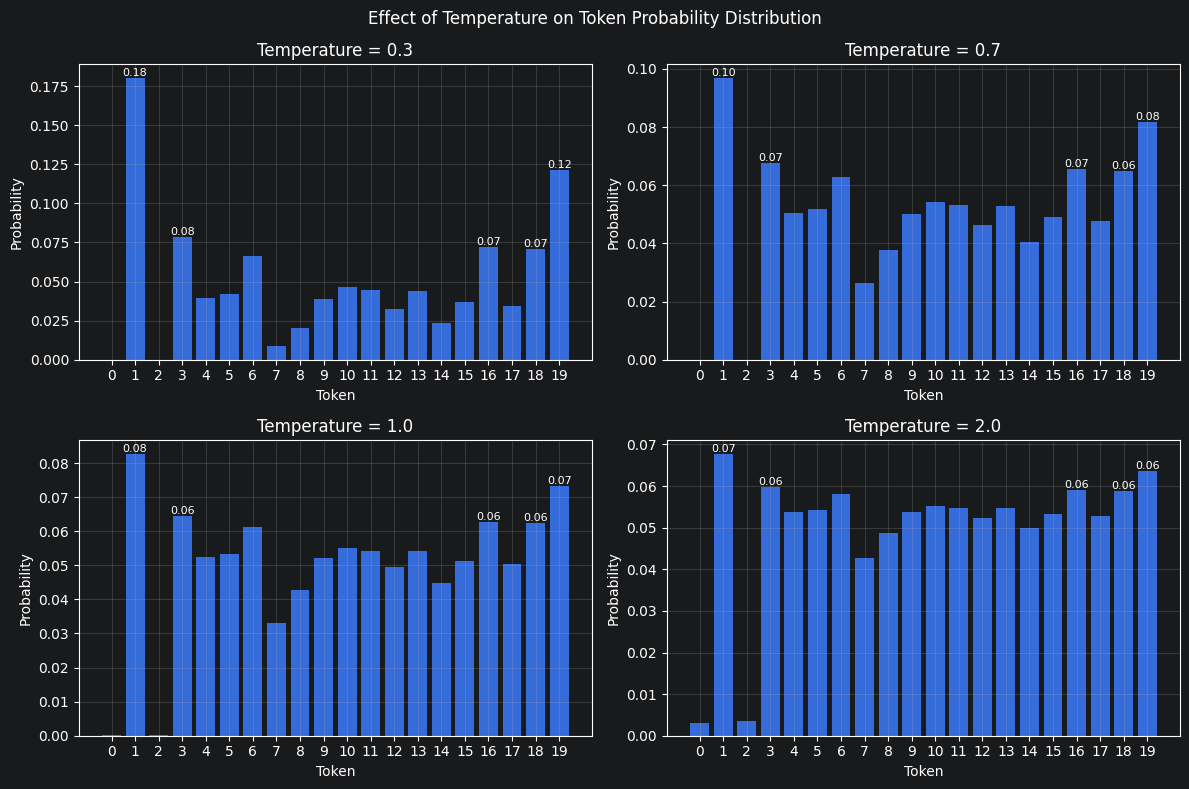

2026-06-05 23:13:46,376 [INFO] gpt: Temperature visualization complete


In [6]:
# Визуализация влияния temperature на распределение вероятностей
temps = [0.3, 0.7, 1.0, 2.0]  # от «холодного» к «горячему»
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

@torch.no_grad()
def get_probs(model, input_ids, temp):
    # Получаем вероятности последнего токена при заданной температуре
    logits = model(input_ids)[:, -1, :]
    return F.softmax(logits / temp, dim=-1)[0].cpu().numpy()

for ax, temp in zip(axes.flat, temps):
    probs = get_probs(gpt, prompt.to(device), temp)
    ax.bar(range(vocab_size), probs)
    ax.set_title(f'Temperature = {temp}')
    ax.set_xlabel('Token')
    ax.set_ylabel('Probability')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(vocab_size))

    # Подписываем top-5 токенов
    top5 = probs.argsort()[-5:][::-1]
    for t in top5:
        ax.text(t, probs[t], f'{probs[t]:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Effect of Temperature on Token Probability Distribution')
plt.tight_layout()
plt.show()


In [7]:
print("=== GPT (Causal Language Model) complete ===")
print("Topics covered:")
print("  - GPT architecture (Decoder-only, causal attention)")  # GPT-архитектура
print("  - Autoregressive generation loop")                       # Авторегрессия
print("  - Greedy decoding (argmax)")                             # Жадный поиск
print("  - Top-k sampling")                                       # Top-k сэмплирование
print("  - Top-p (nucleus) sampling")                             # Top-p (nucleus)
print("  - Temperature scaling")                                  # Temperature
print("  - Comparison of all strategies")                         # Сравнение стратегий


2026-06-05 23:13:49,275 [INFO] gpt: GPT notebook complete


=== GPT (Causal Language Model) complete ===
Topics covered:
  - GPT architecture (Decoder-only, causal attention)
  - Autoregressive generation loop
  - Greedy decoding (argmax)
  - Top-k sampling
  - Top-p (nucleus) sampling
  - Temperature scaling
  - Comparison of all strategies
